# Diabetic Retinopathy Grading - Model Retraining
**Project:** diabetic-retinopathy-xai  
**Models:** EfficientNet-B4 (primary) · ResNet-50 (baseline)  
**Dataset:** IDRiD - 413 train / 103 test  
**Task:** 5-class DR grading (grades 0-4)

---


## 0 · Install Dependencies

In [ ]:
!pip install timm scikit-learn -q

## 1 · Imports

In [ ]:
import os, random, time
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (cohen_kappa_score, classification_report, confusion_matrix)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import timm

import matplotlib.pyplot as plt
import seaborn as sns

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


## 2 · Config

In [ ]:
ROOT = "/content/drive/MyDrive/Projects/diabetic retinopathy/diabetic-retinopathy-xai/data/IDRiD"

GRADING_TRAIN_DIR = os.path.join(ROOT, "grading/images/train")
GRADING_TEST_DIR  = os.path.join(ROOT, "grading/images/test")
TRAIN_CSV         = os.path.join(ROOT, "grading/labels/train.csv")
TEST_CSV          = os.path.join(ROOT, "grading/labels/test.csv")
CKPT_DIR          = "/content/drive/MyDrive/Projects/diabetic retinopathy/diabetic-retinopathy-xai/results/checkpoints"
os.makedirs(CKPT_DIR, exist_ok=True)

IMG_SIZE     = 512
BATCH_SIZE   = 8
NUM_CLASSES  = 5
NUM_EPOCHS   = 30
LR           = 1e-4
WEIGHT_DECAY = 1e-4
SEED         = 42

# 27 XAI-eval images (segmentation test split IDRiD_55–81): leaked into grading/train
EXCLUDED_IDS = [f"IDRiD_{i:03d}" for i in range(55, 82)]
print(f"Excluding {len(EXCLUDED_IDS)} IDs:", EXCLUDED_IDS[0], "...", EXCLUDED_IDS[-1])

Excluding 27 IDs: IDRiD_055 ... IDRiD_081


## 3 · Reproducibility

In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
print("Seed set:", SEED)

Seed set: 42


## 4 · Mount Drive + Load Labels

In [ ]:
!umount -f /content/drive

umount: /content/drive: not mounted.


In [ ]:
!ls /content/drive

MyDrive


In [ ]:
!ls /content/drive/MyDrive/Projects/diabetic\ retinopathy/diabetic-retinopathy-xai
!ls /content/drive/MyDrive/Projects/diabetic\ retinopathy/diabetic-retinopathy-xai/data
!ls /content/drive/MyDrive/Projects/diabetic\ retinopathy/diabetic-retinopathy-xai/data/IDRiD
!ls /content/drive/MyDrive/Projects/diabetic\ retinopathy/diabetic-retinopathy-xai/data/IDRiD/grading
!ls /content/drive/MyDrive/Projects/diabetic\ retinopathy/diabetic-retinopathy-xai/data/IDRiD/grading/labels

data  results  test_image_ids.json
IDRiD
grading  grading.zip  segmentation  segmentation.zip
'B. Disease Grading'   CC-BY-4.0.txt   images   labels	 LICENSE.txt
test.csv  train.csv


In [ ]:
import os
print(os.path.exists(TRAIN_CSV))
print(os.path.exists(TEST_CSV))

True
True


In [ ]:
from google.colab import drive
# drive.flush_and_unmount()
# drive.mount('/content/drive', force_remount=True)

train_df_raw = pd.read_csv(TRAIN_CSV, usecols=["Image name", "Retinopathy grade", "Risk of macular edema "])
test_df      = pd.read_csv(TEST_CSV,  usecols=["Image name", "Retinopathy grade", "Risk of macular edema "])

train_df_raw = train_df_raw.rename(columns={"Risk of macular edema ": "Risk of macular edema"})
test_df      = test_df.rename(columns={"Risk of macular edema ": "Risk of macular edema"})

print("Raw train:", train_df_raw.shape)

# drop the 27 IDs that exist in segmentation-test (XAI eval set)
leaked_in_train = train_df_raw[train_df_raw["Image name"].isin(EXCLUDED_IDS)]
print(f"Leaked rows found in train.csv: {len(leaked_in_train)} / {len(EXCLUDED_IDS)} expected")
assert len(leaked_in_train) == 27, "Expected exactly 27 leaked rows - investigate before proceeding"

train_df = train_df_raw[~train_df_raw["Image name"].isin(EXCLUDED_IDS)].reset_index(drop=True)
print("Clean train:", train_df.shape, f"(removed {len(train_df_raw) - len(train_df)} rows)")

# sanity check: zero overlap with excluded IDs
assert train_df["Image name"].isin(EXCLUDED_IDS).sum() == 0, "Leak still present!"
print("✓ Confirmed zero overlap with XAI eval set (IDs 55–81)")

# saving the cleaned dataframe
train_df.to_csv("/content/drive/MyDrive/Projects/diabetic retinopathy/train_clean.csv", index=False)

Raw train: (413, 3)
Leaked rows found in train.csv: 27 / 27 expected
Clean train: (386, 3) (removed 27 rows)
✓ Confirmed zero overlap with XAI eval set (IDs 55–81)


## 5 · Class Distribution + Weights

Clean train distribution:
 Retinopathy grade
0    134
1     19
2    120
3     68
4     45
Name: count, dtype: int64

Class weights (clean): tensor([0.5761, 4.0632, 0.6433, 1.1353, 1.7156], device='cuda:0')


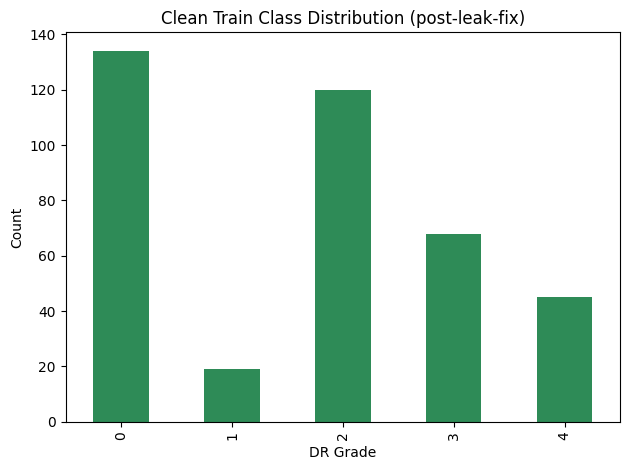

In [ ]:
dist = train_df["Retinopathy grade"].value_counts().sort_index()
print("Clean train distribution:\n", dist)

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1, 2, 3, 4]),
    y=train_df["Retinopathy grade"].values
)
class_weights = torch.tensor(weights, dtype=torch.float32).to(DEVICE)
print("\nClass weights (clean):", class_weights)

dist.plot(kind="bar", title="Clean Train Class Distribution (post-leak-fix)", color="seagreen")
plt.xlabel("DR Grade"); plt.ylabel("Count"); plt.tight_layout(); plt.show()

## 6 · Dataset & DataLoaders

In [ ]:
# transforms
train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.RandomRotation(15),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

val_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# dataloader
class IDRiDDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df        = df.reset_index(drop=True)
        self.img_dir   = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_name = row["Image name"] + ".jpg"
        label    = int(row["Retinopathy grade"])
        image    = Image.open(os.path.join(self.img_dir, img_name)).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

train_dataset = IDRiDDataset(train_df, GRADING_TRAIN_DIR, train_transform)
test_dataset  = IDRiDDataset(test_df,  GRADING_TEST_DIR,  val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# sanity check
print(f"Train batches: {len(train_loader)} | Test batches: {len(test_loader)}")
imgs, lbls = next(iter(train_loader))
print(f"Batch shape: {imgs.shape} | Labels: {lbls}")

Train batches: 49 | Test batches: 13
Batch shape: torch.Size([8, 3, 512, 512]) | Labels: tensor([0, 0, 0, 2, 0, 2, 3, 2])


## 7 · Model Definitions

In [ ]:
def build_efficientnet_b4(num_classes=5, pretrained=True):
    return timm.create_model("efficientnet_b4", pretrained=pretrained, num_classes=num_classes)

def build_resnet50(num_classes=5, pretrained=True):
    import torchvision.models as models
    model = models.resnet50(weights="IMAGENET1K_V1" if pretrained else None)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

# instantiate both
effnet = build_efficientnet_b4().to(DEVICE)
resnet = build_resnet50().to(DEVICE)

# parameter counts
def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

print(f"EfficientNet-B4 params: {count_params(effnet):,}")
print(f"ResNet-50       params: {count_params(resnet):,}")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 156MB/s]


EfficientNet-B4 params: 17,557,581
ResNet-50       params: 23,518,277


## 8 · Training & Evaluation Functions

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs = model(imgs)
            loss    = criterion(outputs, labels)
            total_loss += loss.item() * imgs.size(0)
            preds       = outputs.argmax(1)
            correct    += (preds == labels).sum().item()
            total      += imgs.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    kappa = cohen_kappa_score(all_labels, all_preds, weights="quadratic")
    return total_loss / total, correct / total, kappa, all_preds, all_labels


def plot_history(history, model_name):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(model_name, fontsize=13)
    axes[0].plot(epochs, history["train_loss"], label="train")
    axes[0].plot(epochs, history["val_loss"],   label="val")
    axes[0].set_title("Loss"); axes[0].legend()
    axes[1].plot(epochs, history["train_acc"], label="train")
    axes[1].plot(epochs, history["val_acc"],   label="val")
    axes[1].set_title("Accuracy"); axes[1].legend()
    axes[2].plot(epochs, history["val_kappa"], color="darkorange")
    axes[2].set_title("Val Quadratic Kappa")
    plt.tight_layout(); plt.show()

## 9 · Training Loop

In [ ]:
def train_model(model, model_name, num_epochs=NUM_EPOCHS):
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "val_kappa": []}
    best_kappa = -1.0

    for epoch in range(1, num_epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc, va_kappa, _, _ = evaluate(model, test_loader, criterion)
        scheduler.step()

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(va_acc)
        history["val_kappa"].append(va_kappa)

        elapsed = time.time() - t0
        print(f"[{model_name}] Epoch {epoch:02d}/{num_epochs} | "
              f"Loss {tr_loss:.4f}/{va_loss:.4f} | Acc {tr_acc:.3f}/{va_acc:.3f} | "
              f"Kappa {va_kappa:.4f} | {elapsed:.1f}s")

        if va_kappa > best_kappa:
            best_kappa = va_kappa
            ckpt_path  = os.path.join(CKPT_DIR, f"{model_name}_best.pth")
            torch.save(model.state_dict(), ckpt_path)
            print(f"  ✓ Saved best checkpoint (kappa={best_kappa:.4f})")

    print(f"\n[{model_name}] Best val kappa: {best_kappa:.4f}")
    return history

## 10 · Train EfficientNet-B4

[efficientnet_b4_clean] Epoch 01/30 | Loss 1.6165/1.5496 | Acc 0.339/0.350 | Kappa 0.2507 | 83.9s
  ✓ Saved best checkpoint (kappa=0.2507)
[efficientnet_b4_clean] Epoch 02/30 | Loss 1.3853/1.3988 | Acc 0.383/0.447 | Kappa 0.5034 | 77.0s
  ✓ Saved best checkpoint (kappa=0.5034)
[efficientnet_b4_clean] Epoch 03/30 | Loss 1.1830/1.2436 | Acc 0.516/0.505 | Kappa 0.6333 | 72.2s
  ✓ Saved best checkpoint (kappa=0.6333)
[efficientnet_b4_clean] Epoch 04/30 | Loss 1.0607/1.2570 | Acc 0.573/0.485 | Kappa 0.6060 | 72.0s
[efficientnet_b4_clean] Epoch 05/30 | Loss 1.0168/1.2144 | Acc 0.570/0.534 | Kappa 0.6254 | 73.0s
[efficientnet_b4_clean] Epoch 06/30 | Loss 0.9150/1.1639 | Acc 0.645/0.573 | Kappa 0.7497 | 71.8s
  ✓ Saved best checkpoint (kappa=0.7497)
[efficientnet_b4_clean] Epoch 07/30 | Loss 0.8321/1.1682 | Acc 0.632/0.505 | Kappa 0.6773 | 73.1s
[efficientnet_b4_clean] Epoch 08/30 | Loss 0.7251/1.1856 | Acc 0.707/0.621 | Kappa 0.6587 | 73.0s
[efficientnet_b4_clean] Epoch 09/30 | Loss 0.6386/1.

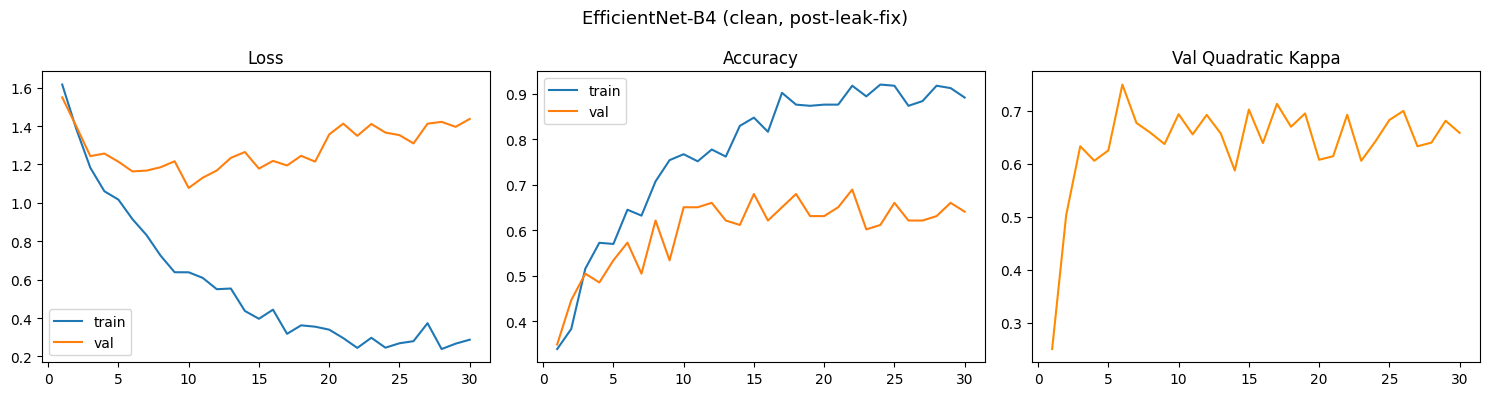

In [ ]:
set_seed(SEED)
effnet   = build_efficientnet_b4().to(DEVICE)
hist_eff = train_model(effnet, "efficientnet_b4_clean")
plot_history(hist_eff, "EfficientNet-B4 (clean, post-leak-fix)")

## 11 · Train ResNet-50 (Baseline)

[resnet50_clean] Epoch 01/30 | Loss 1.3626/1.3281 | Acc 0.430/0.563 | Kappa 0.5961 | 96.9s
  ✓ Saved best checkpoint (kappa=0.5961)
[resnet50_clean] Epoch 02/30 | Loss 1.1450/1.4328 | Acc 0.565/0.495 | Kappa 0.6685 | 89.5s
  ✓ Saved best checkpoint (kappa=0.6685)
[resnet50_clean] Epoch 03/30 | Loss 1.0257/1.1687 | Acc 0.552/0.524 | Kappa 0.7146 | 83.9s
  ✓ Saved best checkpoint (kappa=0.7146)
[resnet50_clean] Epoch 04/30 | Loss 0.9685/1.2561 | Acc 0.588/0.466 | Kappa 0.5565 | 84.5s
[resnet50_clean] Epoch 05/30 | Loss 0.9133/1.1115 | Acc 0.611/0.631 | Kappa 0.7821 | 81.2s
  ✓ Saved best checkpoint (kappa=0.7821)
[resnet50_clean] Epoch 06/30 | Loss 0.8313/1.4032 | Acc 0.637/0.427 | Kappa 0.5805 | 84.4s
[resnet50_clean] Epoch 07/30 | Loss 0.8021/1.4243 | Acc 0.671/0.544 | Kappa 0.6416 | 83.6s
[resnet50_clean] Epoch 08/30 | Loss 0.8049/1.5028 | Acc 0.684/0.388 | Kappa 0.6407 | 79.7s
[resnet50_clean] Epoch 09/30 | Loss 0.6912/1.4279 | Acc 0.728/0.621 | Kappa 0.7332 | 82.1s
[resnet50_clean] 

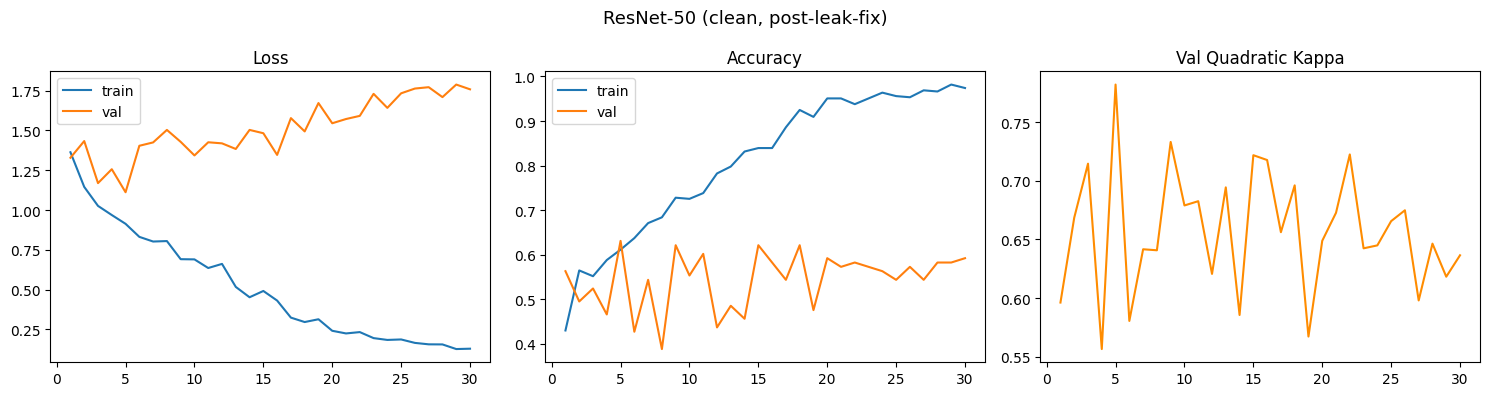

In [ ]:
set_seed(SEED)
resnet   = build_resnet50().to(DEVICE)
hist_res = train_model(resnet, "resnet50_clean")
plot_history(hist_res, "ResNet-50 (clean, post-leak-fix)")

## 12 · Final Evaluation & Comparison


Model: EfficientNet-B4 (clean)
Test Accuracy: 0.5728
Quadratic Kappa: 0.7497

Classification Report:
              precision    recall  f1-score   support

     Grade 0       0.74      0.76      0.75        34
     Grade 1       0.17      0.40      0.24         5
     Grade 2       0.52      0.44      0.47        32
     Grade 3       0.70      0.37      0.48        19
     Grade 4       0.53      0.77      0.62        13

    accuracy                           0.57       103
   macro avg       0.53      0.55      0.51       103
weighted avg       0.61      0.57      0.58       103



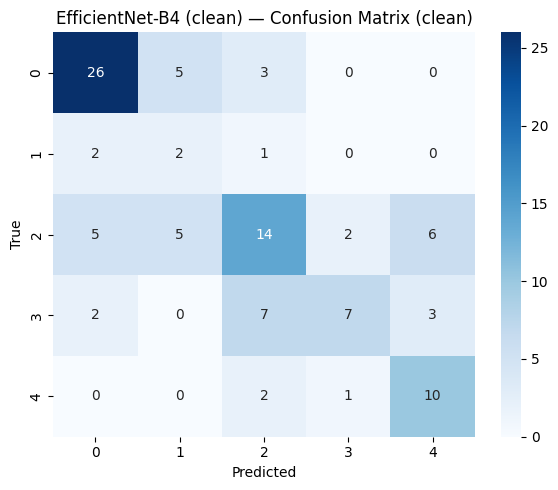


Model: ResNet-50 (clean)
Test Accuracy: 0.6311
Quadratic Kappa: 0.7821

Classification Report:
              precision    recall  f1-score   support

     Grade 0       0.75      0.88      0.81        34
     Grade 1       0.00      0.00      0.00         5
     Grade 2       0.59      0.59      0.59        32
     Grade 3       0.56      0.53      0.54        19
     Grade 4       0.75      0.46      0.57        13

    accuracy                           0.63       103
   macro avg       0.53      0.49      0.50       103
weighted avg       0.63      0.63      0.62       103



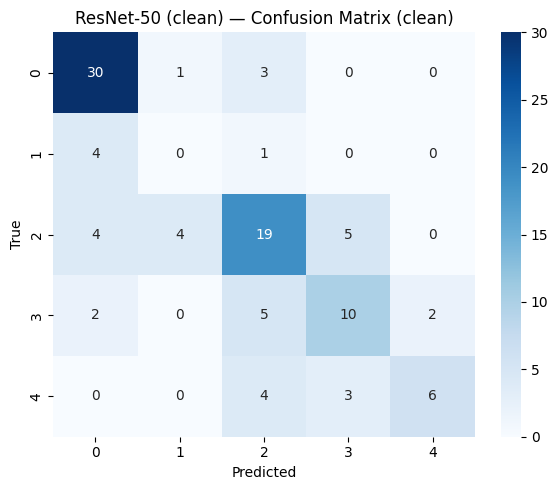


✓ Both models clear kappa > 0.7 threshold on clean data


In [ ]:
def final_eval(model, model_name, ckpt_name):
    ckpt_path = os.path.join(CKPT_DIR, ckpt_name)
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    _, acc, kappa, preds, labels = evaluate(model, test_loader, criterion)
    print(f"\n{'='*50}\nModel: {model_name}\nTest Accuracy: {acc:.4f}\nQuadratic Kappa: {kappa:.4f}\n{'='*50}")
    print("\nClassification Report:")
    print(classification_report(labels, preds,
          target_names=[f"Grade {i}" for i in range(5)]))

    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=range(5), yticklabels=range(5))
    plt.title(f"{model_name} — Confusion Matrix (clean)")
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.tight_layout(); plt.show()
    return kappa

effnet_eval = build_efficientnet_b4().to(DEVICE)
resnet_eval = build_resnet50().to(DEVICE)

k_eff = final_eval(effnet_eval, "EfficientNet-B4 (clean)", "efficientnet_b4_clean_best.pth")
k_res = final_eval(resnet_eval, "ResNet-50 (clean)",       "resnet50_clean_best.pth")

assert k_eff > 0.7, "EfficientNet-B4 below kappa threshold - investigate"
assert k_res > 0.7, "ResNet-50 below kappa threshold - investigate"
print("\n✓ Both models clear kappa > 0.7 threshold on clean data")

## 13 · Save Training History

In [ ]:
import json

results = {"efficientnet_b4_clean": hist_eff, "resnet50_clean": hist_res}
results_path = os.path.join(CKPT_DIR, "training_history_clean.json")
with open(results_path, "w") as f:
    json.dump(results, f, indent=2)

print("Saved:", results_path)

Saved: /content/drive/MyDrive/Projects/diabetic retinopathy/diabetic-retinopathy-xai/results/checkpoints/training_history_clean.json


In [42]:
import torch
ckpt_path1 = "/content/drive/MyDrive/Projects/diabetic retinopathy/diabetic-retinopathy-xai/results/checkpoints/efficientnet_b4_clean_best.pth"
ckpt1 = torch.load(ckpt_path1, map_location="cpu")
print(type(ckpt1))
ckpt_path2 = "/content/drive/MyDrive/Projects/diabetic retinopathy/diabetic-retinopathy-xai/results/checkpoints/resnet50_clean_best.pth"
ckpt2 = torch.load(ckpt_path2, map_location="cpu")
print(type(ckpt2))

<class 'collections.OrderedDict'>
<class 'collections.OrderedDict'>
